# Week 7：紅綠燈遮光挑戰

完整備課版（含參考解答）｜2026-10-21

按開始，看綠燈，遮光再放開，讓有效次數增加；紅燈時新的遮光會扣一次。
OLED顯示倒數與次數，紙指針指出同一個次數。期限前達到6並按結束才過關，
失敗有短聲提示。本週把既有零件組成有規則的作品，不增加新硬體或網路。

### 教學目標

1. 區分光線讀值、分類狀態、新遮光事件及有效次數，解釋持續遮光為何不重複計數。
2. 用雙門檻與穩定時間減少邊界誤觸，指出太短手勢、環境改變及懸空訊號的限制。
3. 以共同時間快照追蹤燈色、計分、結束與期限，預測同輪事件的結果。
4. 依低功率、外部供電、完整遊戲順序整合，對照程式資料與OLED／指針／聲音的實物證據。
5. 保存有局次、原因與時間的紀錄，完成失敗、中止、復原及安全收納，而不把故障算成玩家失敗。

### 教學內容

本週以狀態機（state machine）管理一局遊戲，把感測值轉為可確認的事件，
再依燈色與剩餘時間決定有效次數及結果。學生先用示例推理，再建立低功率版本，
最後加入已核准的舵機指針與有限時間聲音。每個輸出都使用同一份遊戲資料，
並以時間軸、原始紀錄與實體觀察區分「程式判定」和「硬體確實做到」。

## 1. 桌上的每個零件在做什麼

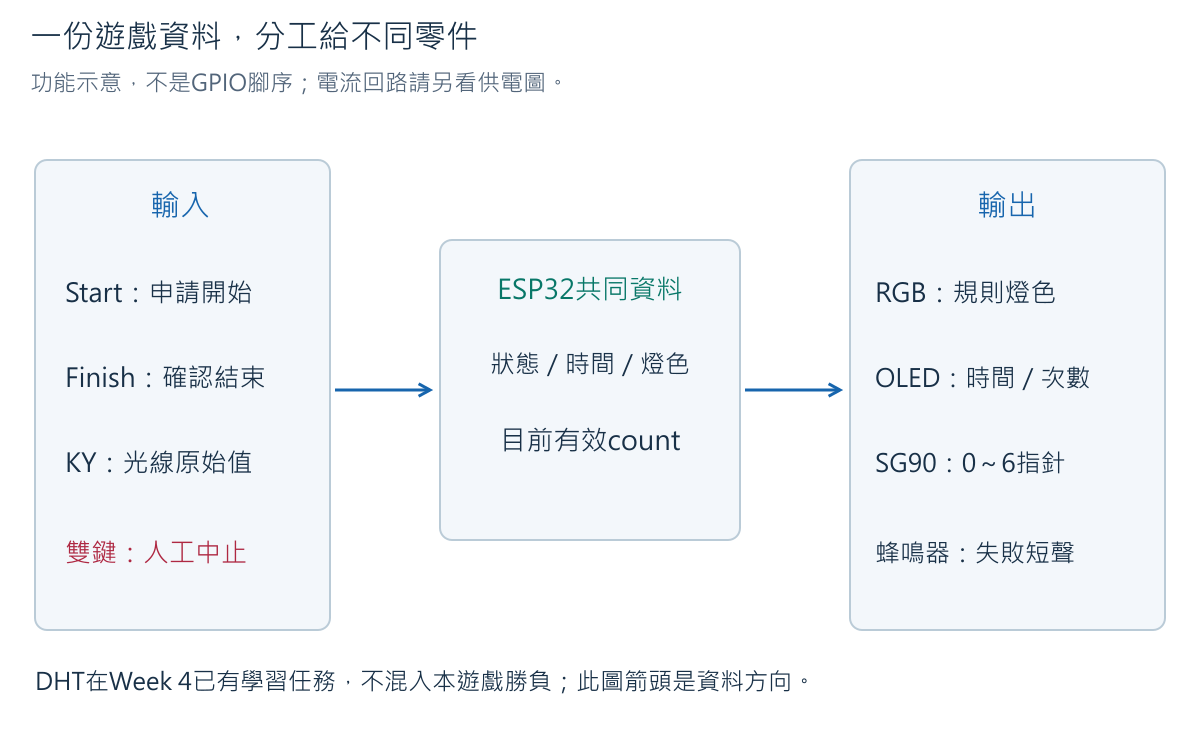

| 零件 | 本週責任 | 容易誤會的地方 |
|---|---|---|
| 第一顆按鈕：開始（Start） | 送出開始新局的請求 | 進行中再按不加時間、不歸零 |
| 第二顆按鈕：結束（Finish） | 確認本局結果；不足6也可以提早結束 | 不是電池電源開關；提早結束不足6是FAILED |
| KY-018光敏模組 | 室內光／遮光的相對訊號 | 不是測室內或室外位置，也不是lux |
| RGB模組 | 綠允許、紅禁止 | 顏色是規則提示，不是導線正負極 |
| OLED | 秒數、次數、規則、結果 | 螢幕刷新不負責創造時間 |
| SG90短紙指針 | 指出目前有效次數0～6 | 不是指向玩家，不推門、不承重 |
| 蜂鳴器 | FAILED後200 ms短聲命令 | ABORTED不發失敗聲；200 ms實際聲長另量測 |
| 核准4AA方案、端子 | 舵機工作電力 | 不把外部正極接3V3、5Vin或GPIO |

DHT11已在Week 4完成獨立與雙感測器任務，本遊戲不拿溫濕度決定勝負，也不要求同時接上它。
兩顆按鈕**同時按住**，或在序列監控視窗（Serial Monitor）送`x`，表示中止（Abort）；
裝置異常時仍先關外部電源、再拔USB。軟體中止不是具電力隔離的急停。

器材使用前提：保留Week 3校正及ADC設定、Week 4蜂鳴器型式與控制介面、
Week 5 RGB／OLED profile、Week 6舵機與外部供電核准紀錄。
缺實物腳位、控制準位、拉高電壓、電流、電池與端子、脈寬／行程任一項，不猜填程式。
[硬體狀態](../docs/hardware/hardware_state.md)中的待驗不能因前週文件完整而自動變成通過。

## 2. 一局遊戲，先用故事讀懂規則

假設30秒目標6次，綠3秒、紅3秒交替。這些是教學設定，不是原廠規格。
開始前光敏已穩定未遮、結束鍵已放開，顯示待機；完整硬體階段還要完成安全準備。

1. 按開始並放開：進入RUNNING，從30秒開始倒數，第一段是綠。
2. 新的穩定遮光：綠燈加1、紅燈扣1；最低0、最高6。
3. 移開遮光物並等穩定：只是重新準備，不加也不扣。
4. 遮住不放：不論讀幾筆、跨過幾次換色，都不補算新手勢。
5. 達6：時間仍走。若再於紅燈遮光，可能6→5。
6. 期限前按結束：當下6為SUCCESS，不足6為FAILED；都停止計時。
7. 到期仍未有效結束：FAILED，即使曾經或目前是6也一樣。
8. 有持續資料問題或人工中止：ABORTED，不當作玩家輸了；先查原因再復原。

**預測練習**：五次綠燈遮光，加一次紅燈遮光，總共六次手勢，可以過關嗎？

**預期答案**：目前有效次數是5−1=4。六次「手勢總數」不是有效6；按結束會失敗。
這是本課選定的遊戲規則，不是感測器直接算分。不要用程式讀到六筆資料替代六次手勢。


## 3. 讀值、狀態、事件、計分：四件不同的事

假設50 ms讀一次：1秒約20筆。遮住1秒的20筆，都可能是SHADE，
但人只做了一次「由未遮到遮住」的轉換。

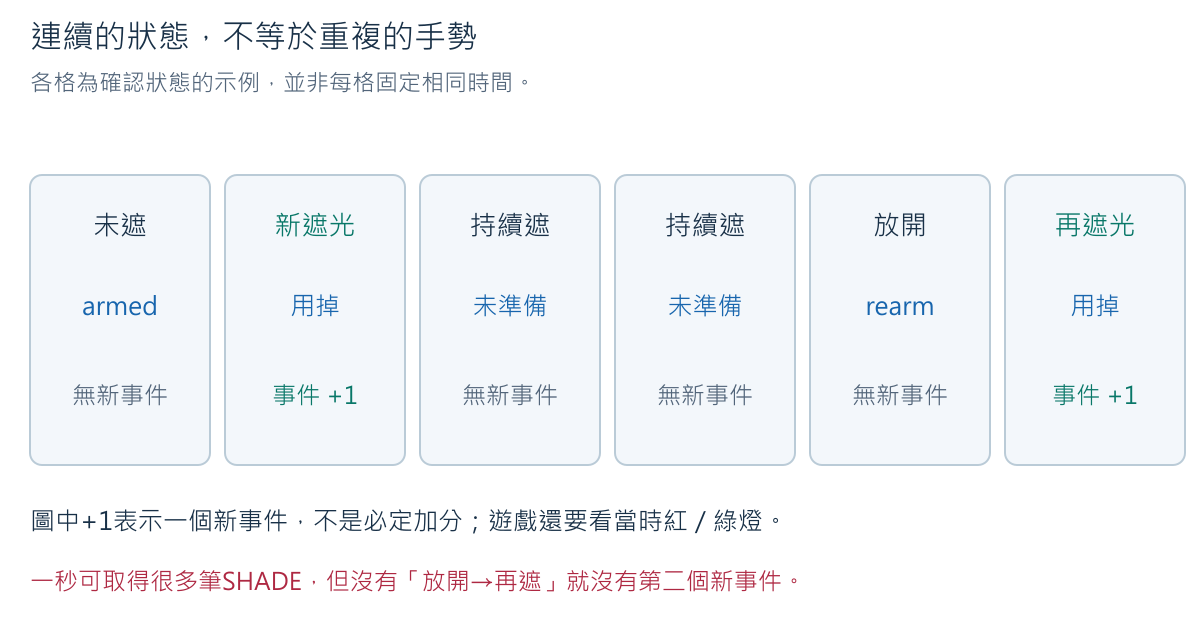

事件（event）表示值得記錄的一次變化。邊緣（edge）在這裡指穩定狀態剛發生轉換，
不是元件外殼的邊。`eventArmed=true`表示已穩定放開，准許下一次遮光事件；
一旦計入新遮光就改false，要再放開才回true。

| 已確認狀態 | armed | 新遮光事件 | 理由 |
|---|---|---|---|
| 未遮光 | true | 無 | 準備下一次 |
| 由未遮轉遮 | 改false | 有 | 用掉這一次準備 |
| 繼續遮住 | false | 無 | 沒有新的轉換 |
| 由遮轉未遮 | 改true | 無 | 放開只重新準備 |

開機時如果已遮住，不能先送一次事件；要先穩定移開。這避免玩家手還放在上面時，
重啟就白得一次。結果狀態也不再計分，不能靠結束後不停遮光改結果。

### 3.1 為什麼還要雙門檻？

Week 3用一個門檻把raw轉字串。假設門檻610，609、611來回時字串可能跳動。
本週採雙門檻的滯後帶（hysteresis band）加穩定確認：
兩端才能提出新分類，中間先不確認。這是本課保守的事件濾波策略，不是改造ADC硬體。

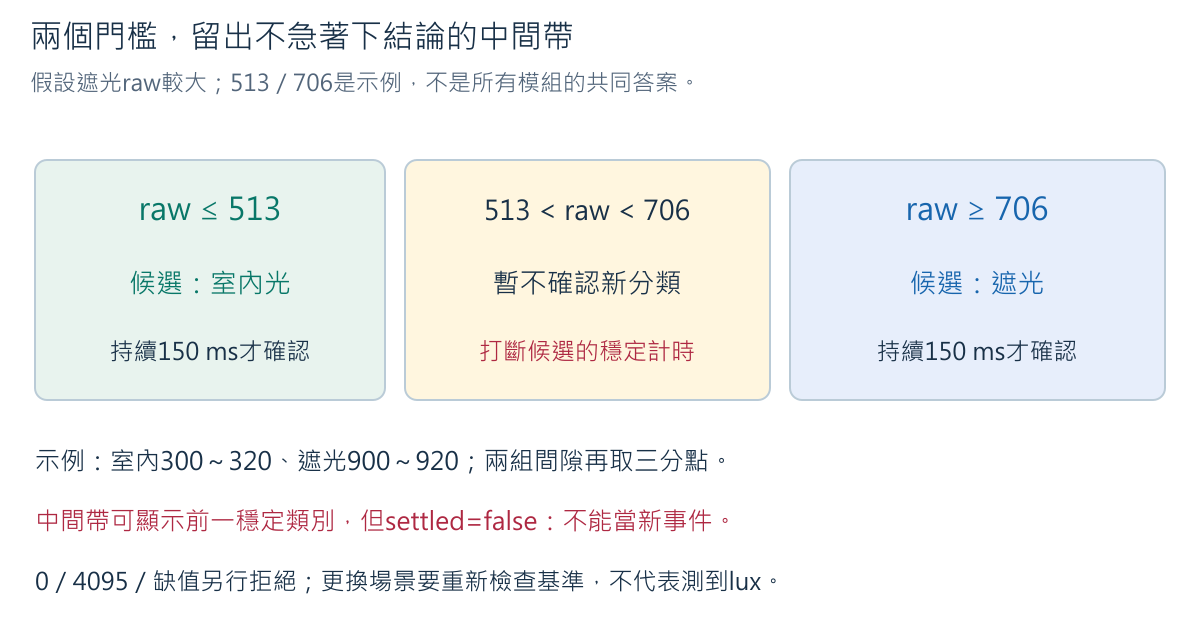

假設原基準為室內300～320、遮光900～920，間隙900−320=580：

```text
lower = 320 + 580÷3 的整數部分 = 513
upper = 320 + (2×580)÷3 的整數部分 = 706
raw ≤ 513：候選室內光
raw ≥ 706：候選遮光
513 < raw < 706：暫不確認新分類
```

這些示例不是全班固定值。實際用自己的四個min/max，兩組必須分開且間隙至少3個raw單位，
否則程式阻擋；「至少3」只是能放兩個不同整數門檻的最低條件，不證明辨識品質很好。
若遮光較小，程式反轉兩側的標籤，不強迫所有板子都遮光較大。

### 3.2 150 ms穩定，不是遮一下立刻得分

同一候選需持續150 ms才成為穩定狀態。每50 ms取樣，候選在0 ms出現，
50、100 ms仍相同，150 ms才確認；是四筆跨三個間隔，不是三筆就150 ms。
手勢正好出現在兩次取樣之間，還有等待下次取樣的時間，加上輸出工作延遲，
所以不能宣稱實體反應固定150 ms。

中間值會清掉尚未完成的候選確認，顯示可保留前一穩定分類但`settled=false`；
不能拿這個舊分類產生新事件。0、4095或注入−1視為本練習不可用，清除穩定分類與armed。
兩端ADC值不一定表示硬體損壞，只是本課先拒絕可能飽和／無法支持判定的資料。

**練習**：室內已穩定後，raw依時間為0 ms:900、50:900、100:600、150:900、200:900。
到200 ms有遮光事件嗎？

**預期答案**：沒有。100 ms的中間值打斷候選，150 ms重新開始；到200只持續50 ms。
若後續250、300仍900，300 ms才確認。不是把多段零散遮光時間加總。

### 3.3 什麼情況不算玩家失敗？

短暫轉換不計分，但時間繼續；持續2000 ms無法到達穩定可判斷狀態則中止。
最近一筆樣本超過200 ms沒有更新，也中止進行中的遊戲，避免拿很舊的狀態繼續算分。
這是可調教學參數，必須記錄並測試，不能忽略正常操作是否容易誤觸中止。

讀得到合理raw仍可能是線鬆、光照干擾或錯誤方向，程式無法自動抓到所有實體故障。
本例`valid=true`只表示最近樣本新鮮、分類已穩定且未注入缺值；不證明感測精度、
是否仍在原min/max區間或所有接線正常。超出原基準但仍在0～4095內的值可能仍被分類，
要回看原始log與場景；不能因此宣稱是永久有效的室內／遮光分類器。


## 4. 同一輪發生兩件事，先算哪個？

程式一輪先取`now`，讀按鈕與本次樣本，得到輸入快照（snapshot）。
它表示一輪處理所使用的觀察，不表示硬體在同一微秒同時取樣。

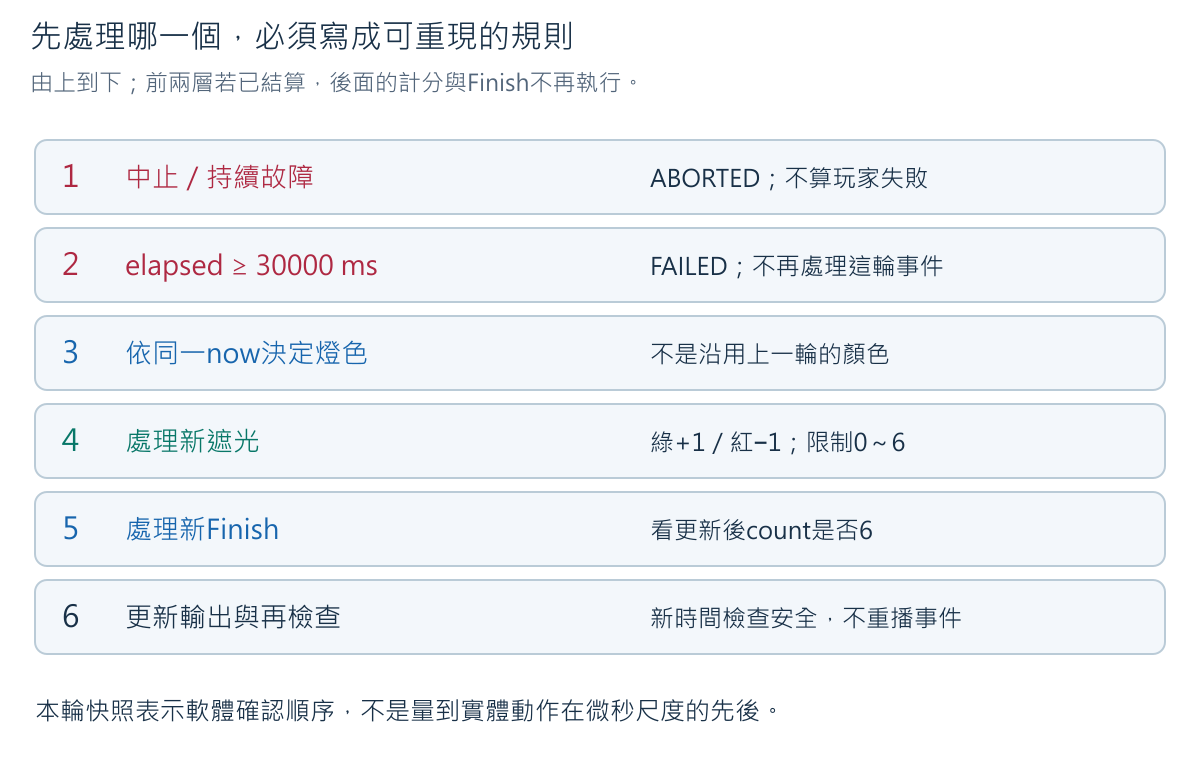

1. 中止／持續故障先處理，不把裝置問題計為玩家輸。
2. 經過時間≥30000 ms先逾時，不再處理該輪遮光或Finish。
3. 依同一now決定燈色：0～2999 ms綠，3000～5999紅，6000～8999綠，依此交替。
4. 新遮光依第3步燈色更新count，綠上限6、紅下限0。
5. 新Finish依更新後count結算。
6. 依相同資料更新輸出；顯示傳送後再以新時間檢查安全與期限，不重播事件。

**例一**：elapsed=12000 ms、count5，同輪確認新遮光和Finish。
12000÷3000=4，是綠段；先加成6，再判成功。

**例二**：elapsed=15000 ms、count6，同輪兩事件。
15000÷3000=5，是紅段；先扣成5，再判失敗。

**例三**：elapsed=30000 ms、count6、有Finish。
期限優先，失敗。不能用螢幕上一幀仍顯示1秒，要求程式補一秒。

同輪第六次與Finish可成功，但指針可能尚未移到6就被停止脈波。
此時OLED結果依規則凍結，指針不能冒充精準的結果回饋。一般遊玩應先看次數，
再按結束；邊界案例用邏輯測試確認，不要求學生用手做出精確同一毫秒。

### 4.1 跨色保持，不補算事件

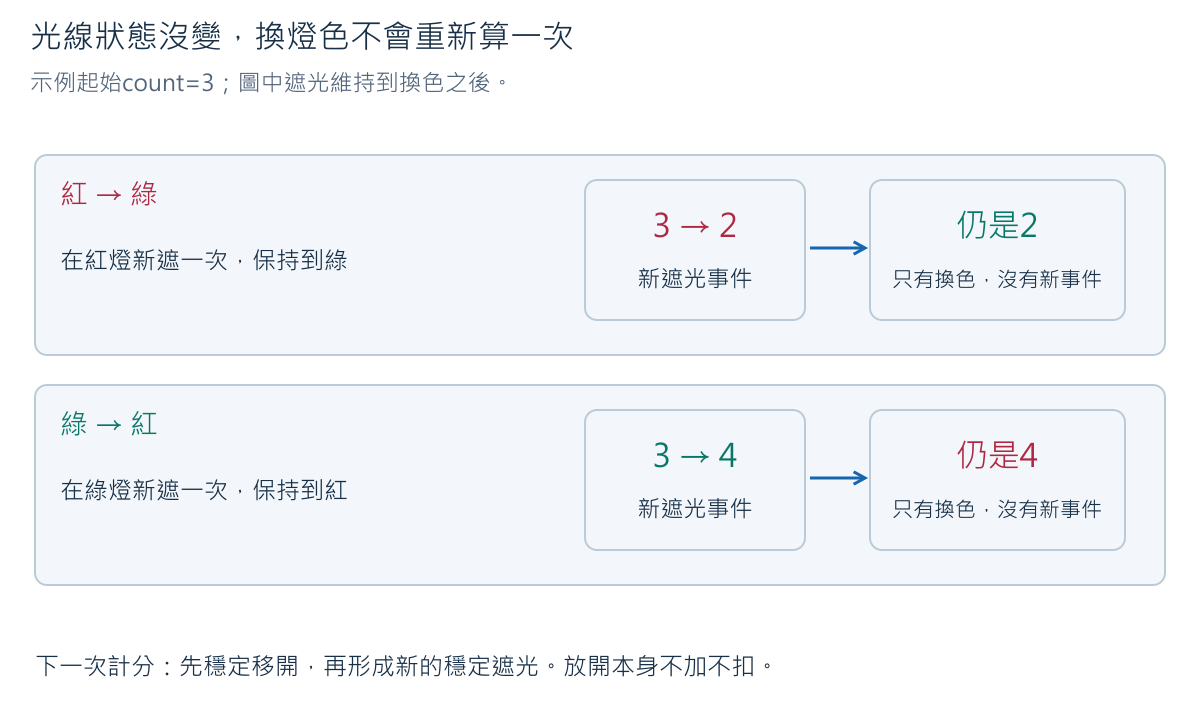

紅燈出現一次新遮光，扣一次後持續遮到綠燈，不自動加1。
綠燈新遮光加一次後持續到紅燈，也不自動扣1。計的是「新事件發生時的燈色」，
不是「每一筆資料碰上什麼色」。只有穩定放開再遮住才有下一事件。

## 5. 狀態機：明確決定此刻允許什麼

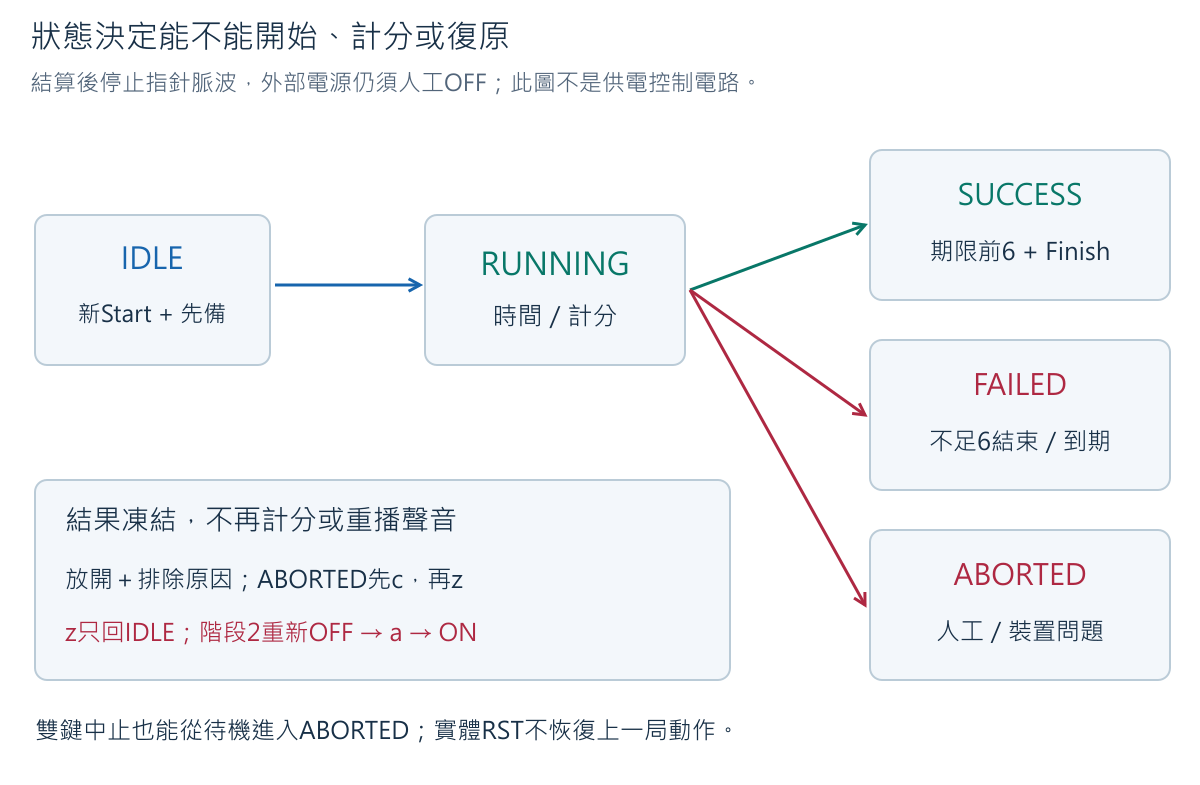

| 狀態 | 次數／時間 | RGB、聲音、指針 | 下一步 |
|---|---|---|---|
| IDLE | 0、30秒尚未走 | RGB關、靜音；指針未啟用或已人工安全準備 | 新Start且所有先備成立 |
| RUNNING | 事件計分、依時間差倒數 | 顯示燈色、靜音、指針跟count | Finish、到期或中止 |
| SUCCESS | 凍結 | RGB關、靜音、停指針脈波 | 放開鍵、安全關電後z |
| FAILED | 凍結 | RGB關、短聲一次後關、停指針脈波 | 同上 |
| ABORTED | 凍結，不當競賽結果 | RGB關、靜音、停指針脈波 | 原因排除→c→z |

所有結果不再計分。兩鍵持續按住時c、z、a、Start均不能開始新局；
放開只是符合條件，不自動reset。實體RST重新開機回待機，舵機預設不attach。
若結果已SUCCESS或FAILED，之後的安全中止只停輸出，不改寫已結算的結果；
仍須排除造成停止的條件才能準備下一局。

完整階段的`a`不是Start：它表示操作人員已將舵機外部電源OFF，程式準備0的脈波。
核准上電順序後人工ON並確認無異常，才按Start。準備超過20秒未開始會ABORTED、停脈波，
防止無限期保持；程式沒有量電池ON／OFF，也沒確認真正角度。


## 6. 先畫接線責任，再碰電源

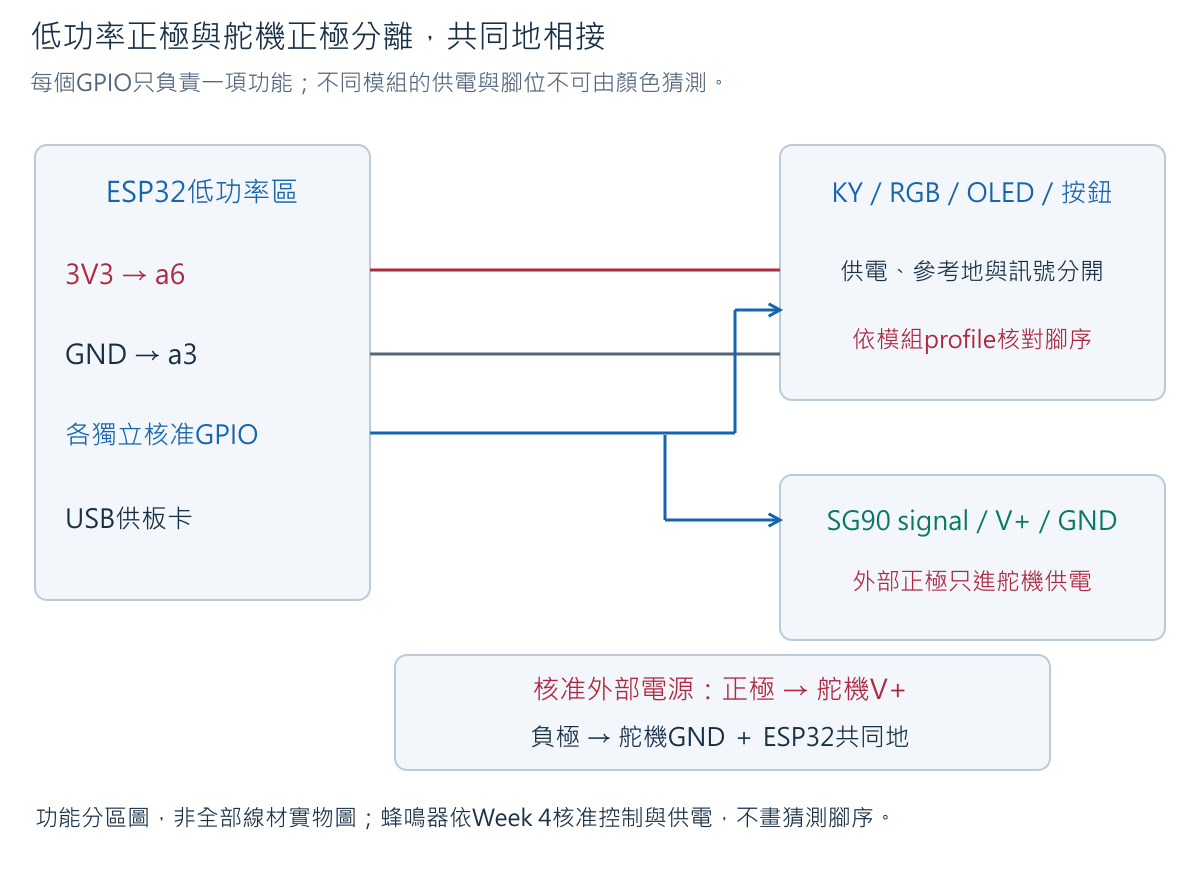

先拔USB、外部OFF並取出電池。延續原有3V3→a6、GND→a3、S→a15／c15→ADC的節點。
只有同側同列a～e內相通，不把a15與f15、a3與a6當同一點。

| 功能路徑 | 接線／來源 | 核對理由 |
|---|---|---|
| 3V3低功率列 | ESP32 3V3→a6；KY中間供電→c6；核准OLED VCC→b6 | 保留e6為量測端；供電相容性先核准 |
| 共同參考地 | ESP32 GND→a3；KY−→c3；OLED GND→b3；d3引到核准共地端子 | e3可量測，不把地線接到正極 |
| KY訊號 | S→a15；c15→PIN_LIGHT | e15保留測點，GPIO為ADC功能核准腳 |
| Start | PIN_START→a20；按鈕一組→b20，另一組→共地端子 | 按住LOW、放開靠內部上拉HIGH |
| Finish | PIN_FINISH→a25；第二按鈕一組→b25，另一組→共地端子 | 不與Start共用輸入線，不看四腳外觀猜電氣組 |
| RGB三路 | 三個獨立核准GPIO→實物R／G／B功能腳 | 共同端及限流依已驗證型式，不能假設所有模組共陰 |
| OLED通訊 | PIN_SDA→SDA、PIN_SCL→SCL | 分開的核准GPIO，位址和控制器不可互相推定 |
| 蜂鳴器（階段2） | PIN_BUZZER→已核准控制端；供電／GND依Week 4核准profile | 本程式適用可用有效準位控制的已核准模組，不是任意裸蜂鳴器 |
| 舵機（階段2） | PIN_SERVO→signal；核准外部正極→V+；外部負極→SG90 GND及共地端子 | 不讓馬達工作電流走GPIO；外部正極不連3V3／5Vin |

b20與b25是各按鈕的延伸節點，不要求兩顆按鈕直接照這兩孔插；
依已驗證腳距固定按鈕，再用導線連到指定組，兩電氣組不落同一連通列。
共地端子及舵機供電線須能安全固定並承受核准負載，不把任意裸線塞母頭。

此圖和表只指定功能，不替未核准模組畫出上電腳序。RGB共同端、蜂鳴器供電、
舵機三線與OLED腳序均使用本批核准profile；沒有它就不進對應硬體階段。

上電前依序核對：外部正極與低功率正極分開、每條GND去向、每個GPIO只負責一項功能、
按鈕放開／按下關係、電表孔位與檔位、接頭不鬆脫。無蜂鳴不能證明所有安全條件通過。
需要通斷／電阻測試時必須與所有外部電源分離；帶電不轉Ω檔，不靠拔線製造錯誤。

## 7. 完整程式與設定

依賴：ESP32 core 3.3.11、U8g2 2.36.15、ESP32Servo 3.2.1。
範例OLED建構子只適用已核准SSD1306 128×64 I2C；若實物不同，先修正建構子並驗證，
不只改位址碰碰運氣。Stage 1仍需ESP32Servo編譯，但不啟動舵機通道。

完整來源：[week07_traffic_light_challenge.ino](../examples/week07_traffic_light_challenge/week07_traffic_light_challenge.ino)。
先保持`LESSON_STAGE=0`、profile=false與GPIO=-1。只有核准完成的設定才填入，
不是見到blocked就把全部false改true。


In [ ]:
#include <Arduino.h>
#include <Wire.h>
#include <U8g2lib.h>
#include <ESP32Servo.h>
#include <esp_system.h>

// 0: blocked; 1: verified low-power game; 2: add verified servo + buzzer.
const int LESSON_STAGE = 0;
const char* DEVICE_ID = "BOARD-T01";
const bool LOW_POWER_PROFILE_CONFIRMED = false;
const bool SERVO_AND_POWER_PROFILE_CONFIRMED = false;
const bool BUZZER_PROFILE_CONFIRMED = false;
const int PIN_LIGHT = -1;
const int PIN_START = -1;
const int PIN_FINISH = -1;
const int PIN_RGB_R = -1;
const int PIN_RGB_G = -1;
const int PIN_RGB_B = -1;
const int RGB_ON_LEVEL = -1;
const int PIN_SDA = -1;
const int PIN_SCL = -1;
const int OLED_ADDRESS_7BIT = -1;
const int PIN_SERVO = -1;
const int PIN_BUZZER = -1;
const int BUZZER_ON_LEVEL = -1;
const int SERVO_HZ = -1;
const int SERVO_MIN_US = -1;
const int SERVO_MAX_US = -1;
const int SAFE_MIN_ANGLE = -1;
const int SAFE_MAX_ANGLE = -1;
const int ZERO_ANGLE = -1;
const int SIX_ANGLE = -1;
const int INDOOR_MIN = -1;
const int INDOOR_MAX = -1;
const int SHADE_MIN = -1;
const int SHADE_MAX = -1;

const uint32_t GAME_MS=30000, COLOR_MS=3000, SAMPLE_MS=50, STABLE_MS=150;
const uint32_t BUTTON_MS=30, UNSETTLED_LIMIT_MS=2000, SAMPLE_STALE_MS=200;
const uint32_t DISPLAY_MS=200, LOG_MS=500, BEEP_MS=200, PREPARE_LIMIT_MS=20000;
const int TARGET=6;
U8G2_SSD1306_128X64_NONAME_F_HW_I2C oled(U8G2_R0,U8X8_PIN_NONE,PIN_SCL,PIN_SDA);
Servo pointer;
enum GameState { IDLE, RUNNING, SUCCESS, FAILED, ABORTED };
enum LightState { UNKNOWN=-1, INDOOR=0, SHADE=1 };
GameState state=IDLE;
LightState stable=UNKNOWN,candidate=UNKNOWN;
bool ready=false,shadeHigh=true,lightSettled=false,eventArmed=false,hadSample=false;
bool unsettled=true,injectedFault=false,ioFault=false,cleared=false,prepared=false;
bool greenPhase=false,buzzerOn=false,dirty=true;
int lowerThreshold=-1,upperThreshold=-1,lightRaw=-1,count=0,angleCommand=-1;
uint32_t bootId=0,gameId=0,startedAt=0,frozenRemaining=GAME_MS,candidateAt=0;
uint32_t unsettledAt=0,lastSample=0,lastDraw=0,lastLog=0,beepAt=0,preparedAt=0;
const char* reason="boot_idle";
struct Button {
 bool raw=false,candidate=false,stable=false,edge=false;
 uint32_t changedAt=0;
 void update(bool pressed,uint32_t now){
  raw=pressed;edge=false;
  if(pressed!=candidate){candidate=pressed;changedAt=now;}
  if(candidate!=stable && now-changedAt>=BUTTON_MS){stable=candidate;edge=stable;}
 }
 bool released(uint32_t now)const{return !raw&&!stable&&!candidate&&now-changedAt>=BUTTON_MS;}
};
Button startButton,finishButton;

bool profileReady(){
 if(LESSON_STAGE<1||LESSON_STAGE>2||!LOW_POWER_PROFILE_CONFIRMED)return false;
 if(RGB_ON_LEVEL!=LOW&&RGB_ON_LEVEL!=HIGH)return false;
 if(OLED_ADDRESS_7BIT<8||OLED_ADDRESS_7BIT>119)return false;
 if(INDOOR_MIN<=0||SHADE_MIN<=0||INDOOR_MAX>=4095||SHADE_MAX>=4095||
    INDOOR_MIN>INDOOR_MAX||SHADE_MIN>SHADE_MAX)return false;
 shadeHigh=INDOOR_MAX<SHADE_MIN;
 if(!shadeHigh && !(SHADE_MAX<INDOOR_MIN))return false;
 const int lowEnd=shadeHigh?INDOOR_MAX:SHADE_MAX;
 const int highBegin=shadeHigh?SHADE_MIN:INDOOR_MIN;
 if(highBegin-lowEnd<3)return false;
 lowerThreshold=lowEnd+(highBegin-lowEnd)/3;
 upperThreshold=lowEnd+2*(highBegin-lowEnd)/3;
 const int pins[]={PIN_LIGHT,PIN_START,PIN_FINISH,PIN_RGB_R,PIN_RGB_G,PIN_RGB_B,
                   PIN_SDA,PIN_SCL,PIN_SERVO,PIN_BUZZER};
 const int size=LESSON_STAGE==2?10:8;
 for(int i=0;i<size;i++){if(pins[i]<0)return false;for(int j=0;j<i;j++)if(pins[i]==pins[j])return false;}
 if(LESSON_STAGE==2 && (!SERVO_AND_POWER_PROFILE_CONFIRMED||!BUZZER_PROFILE_CONFIRMED||
    (BUZZER_ON_LEVEL!=LOW&&BUZZER_ON_LEVEL!=HIGH)||SERVO_HZ<10||SERVO_HZ>400||
    SERVO_MIN_US<500||SERVO_MAX_US>2500||SERVO_MIN_US>=SERVO_MAX_US||
    SAFE_MIN_ANGLE<0||SAFE_MAX_ANGLE>180||SAFE_MIN_ANGLE>ZERO_ANGLE||
    ZERO_ANGLE>=SIX_ANGLE||SIX_ANGLE>SAFE_MAX_ANGLE))return false;
 return true;
}
const char* stateName(){switch(state){case IDLE:return "IDLE";case RUNNING:return "RUNNING";
 case SUCCESS:return "SUCCESS";case FAILED:return "FAILED";default:return "ABORTED";}}
const char* lightName(){return stable==SHADE?"SHADE":stable==INDOOR?"INDOOR":"UNKNOWN";}
bool terminal(){return state==SUCCESS||state==FAILED||state==ABORTED;}
uint32_t remainingAt(uint32_t now){return state==RUNNING?(now-startedAt>=GAME_MS?0:GAME_MS-(now-startedAt)):frozenRemaining;}
uint32_t displaySeconds(uint32_t ms){return (ms+999)/1000;}
bool bothReleased(uint32_t now){return startButton.released(now)&&finishButton.released(now);}
bool fresh(uint32_t now){return hadSample&&now-lastSample<=SAMPLE_STALE_MS;}
bool oledAck(){Wire.beginTransmission(OLED_ADDRESS_7BIT);return Wire.endTransmission()==0;}
void rgbOff(){const int off=1-RGB_ON_LEVEL;digitalWrite(PIN_RGB_R,off);digitalWrite(PIN_RGB_G,off);digitalWrite(PIN_RGB_B,off);}
void rgbPhase(){rgbOff();digitalWrite(greenPhase?PIN_RGB_G:PIN_RGB_R,RGB_ON_LEVEL);}
void silence(){if(LESSON_STAGE==2)digitalWrite(PIN_BUZZER,1-BUZZER_ON_LEVEL);buzzerOn=false;}
void detachPointer(){if(LESSON_STAGE==2){if(pointer.attached())pointer.detach();digitalWrite(PIN_SERVO,LOW);}prepared=false;}
int angleForCount(int n){return ZERO_ANGLE+(SIX_ANGLE-ZERO_ANGLE)*n/TARGET;}
void logEvent(const char* type,const char* why,uint32_t now,int before){
 Serial.printf("device_id=%s boot_id=%08lx game_id=%lu event_type=%s state=%s value=%d unit=count "
  "valid=%s reason=%s uptime_ms=%lu phase=%s light_raw=%d light_state=%s settled=%s armed=%s "
  "count_before=%d count_after=%d remaining_ms=%lu result=%s angle_command=%d position_measured=false\n",
  DEVICE_ID,(unsigned long)bootId,(unsigned long)gameId,type,stateName(),count,
  fresh(now)&&lightSettled&&!injectedFault?"true":"false",why,(unsigned long)now,
  state==RUNNING?(greenPhase?"GREEN":"RED"):"OFF",lightRaw,lightName(),lightSettled?"true":"false",
  eventArmed?"true":"false",before,count,(unsigned long)remainingAt(now),stateName(),angleCommand);
}
void writePointer(uint32_t now){
 if(LESSON_STAGE==2&&pointer.attached()){
  angleCommand=angleForCount(count);pointer.write(angleCommand);logEvent("pointer_command","count_mapping",now,count);
 }
}
void settle(GameState target,const char* why,uint32_t now){
 if(terminal()){if(target==ABORTED){silence();detachPointer();rgbOff();}return;}
 if(target!=ABORTED&&state!=RUNNING)return;
 frozenRemaining=remainingAt(now);state=target;reason=why;cleared=false;dirty=true;
 rgbOff();silence();detachPointer();
 if(target==FAILED&&LESSON_STAGE==2){digitalWrite(PIN_BUZZER,BUZZER_ON_LEVEL);buzzerOn=true;beepAt=now;}
 logEvent("result",why,now,count);
}
// Confirm an event only after a classified value remains for STABLE_MS.
// Middle-band readings keep the displayed previous state, but cannot confirm or rearm.
bool sampleLight(int raw,uint32_t now){
 lightRaw=raw;lastSample=now;hadSample=true;
 LightState next=UNKNOWN;
 if(raw>0&&raw<4095){if(raw<=lowerThreshold)next=shadeHigh?INDOOR:SHADE;
  else if(raw>=upperThreshold)next=shadeHigh?SHADE:INDOOR;}
 if(next==UNKNOWN){candidate=UNKNOWN;candidateAt=now;lightSettled=false;
  if(raw<=0||raw>=4095){stable=UNKNOWN;eventArmed=false;}
 }else{
  if(next!=candidate){candidate=next;candidateAt=now;}
  lightSettled=now-candidateAt>=STABLE_MS;
  if(lightSettled){
   const bool changed=stable!=next;stable=next;
   if(next==INDOOR)eventArmed=true;
   if(next==SHADE&&changed){const bool event=eventArmed;eventArmed=false;unsettled=false;return event;}
  }
 }
 if(lightSettled)unsettled=false;
 else if(!unsettled){unsettled=true;unsettledAt=now;}
 return false;
}
bool persistentFault(uint32_t now){return unsettled&&now-unsettledAt>=UNSETTLED_LIMIT_MS;}
void stepGame(uint32_t now,bool startEdge,bool finishEdge,bool coverEdge,bool abortRequest){
 // One snapshot, fixed priority: abort -> deadline -> color -> score -> finish.
 if(abortRequest||ioFault||(state==RUNNING&&(!fresh(now)||persistentFault(now)))){
  settle(ABORTED,abortRequest?"manual_or_both_buttons":ioFault?"display_ack_failed":"light_unavailable",now);return;
 }
 if(state==IDLE){
  if(LESSON_STAGE==2&&prepared&&now-preparedAt>=PREPARE_LIMIT_MS){settle(ABORTED,"prepare_timeout",now);return;}
  if(startEdge){
   if(!finishButton.raw&&!finishButton.stable&&finishButton.released(now)&&fresh(now)&&
      lightSettled&&stable==INDOOR&&!injectedFault&&(LESSON_STAGE==1||prepared)){
    state=RUNNING;gameId++;startedAt=now;frozenRemaining=GAME_MS;count=0;greenPhase=true;
    reason="start_accepted";eventArmed=true;rgbPhase();dirty=true;logEvent("start",reason,now,0);
   }else logEvent("start_rejected","release_finish_uncover_or_prepare",now,count);
  }
  return;
 }
 if(state!=RUNNING)return;
 if(now-startedAt>=GAME_MS){settle(FAILED,"deadline",now);return;}
 const bool nextGreen=((now-startedAt)/COLOR_MS)%2==0;
 if(nextGreen!=greenPhase){greenPhase=nextGreen;rgbPhase();dirty=true;logEvent("phase","clock_phase",now,count);}
 if(coverEdge){const int before=count;
  count=greenPhase?(count<TARGET?count+1:TARGET):(count>0?count-1:0);
  dirty=true;logEvent("cover",greenPhase?"green_credit":"red_penalty",now,before);
  if(count!=before)writePointer(now);
 }
 if(finishEdge)settle(count==TARGET?SUCCESS:FAILED,count==TARGET?"finish_target":"finish_below_target",now);
}
void handleCommand(char c,uint32_t now){
 if(c=='\r'||c=='\n'||c==' ')return;
 if(c=='x'){settle(ABORTED,"manual_abort",now);return;}
 if(c=='f'){injectedFault=true;sampleLight(-1,now);logEvent("fault_injection","software_missing_not_wire_removal",now,count);return;}
 if(c=='r'){injectedFault=false;logEvent("injection_removed","wait_new_stable_sample",now,count);return;}
 if(c=='c'&&state==ABORTED&&bothReleased(now)&&fresh(now)&&lightSettled&&!injectedFault){
  ioFault=!oledAck();cleared=!ioFault;logEvent("clear",cleared?"reset_required":"display_still_unresponsive",now,count);return;
 }
 if(c=='z'&&terminal()&&bothReleased(now)&&fresh(now)&&lightSettled&&!injectedFault&&!ioFault&&
    (state!=ABORTED||cleared)){
  silence();detachPointer();state=IDLE;count=0;angleCommand=-1;frozenRemaining=GAME_MS;
  cleared=false;reason="reset_idle_not_started";dirty=true;logEvent("reset",reason,now,0);return;
 }
 // Operator must have external servo power OFF and the approved power sequence.
 if(c=='a'&&LESSON_STAGE==2&&state==IDLE&&!prepared&&bothReleased(now)&&fresh(now)&&lightSettled&&
    stable==INDOOR&&!ioFault&&!injectedFault){
  pointer.setPeriodHertz(SERVO_HZ);pointer.attach(PIN_SERVO,SERVO_MIN_US,SERVO_MAX_US);
  if(!pointer.attached()){settle(ABORTED,"attach_failed",now);return;}
  prepared=true;preparedAt=now;count=0;writePointer(now);dirty=true;
  logEvent("prepare","operator_power_off_acknowledged_not_sensed",now,count);return;
 }
 logEvent("command_rejected","state_or_guard",now,count);
}
void drawSnapshot(uint32_t now){
 if(ioFault)return;
 if(!oledAck()){ioFault=true;settle(ABORTED,"display_ack_failed",now);return;}
 char s[26];oled.clearBuffer();oled.setFont(u8g2_font_6x12_tf);
 oled.drawStr(0,12,stateName());
 snprintf(s,sizeof(s),"TIME %lu s  %d/6",(unsigned long)displaySeconds(remainingAt(now)),count);oled.drawStr(0,28,s);
 const char* hint=state==RUNNING?(greenPhase?"GREEN: COVER":"RED: NO COVER"):
  state==SUCCESS?"PASS / RESET z":state==FAILED?"FAIL / RESET z":state==ABORTED?"ABORT / CHECK LOG":
  LESSON_STAGE==1?"UN COVER / START":prepared?"READY / START":"POWER OFF / ARM a";
 oled.drawStr(0,44,hint);oled.drawStr(0,60,LESSON_STAGE==1?"STAGE1: NO SERVO/BEEP":pointer.attached()?"POINTER: COMMAND ONLY":"POINTER: NO SIGNAL");
 oled.sendBuffer();
 if(!oledAck()){ioFault=true;settle(ABORTED,"display_ack_failed",millis());}
}
void setup(){
 Serial.begin(115200);delay(1000);
 if(!profileReady()){Serial.println("week=7 status=blocked reason=profile_missing");return;}
 ready=true;bootId=esp_random();unsettledAt=millis();
 for(int p:{PIN_RGB_R,PIN_RGB_G,PIN_RGB_B}){digitalWrite(p,1-RGB_ON_LEVEL);pinMode(p,OUTPUT);}
 pinMode(PIN_START,INPUT_PULLUP);pinMode(PIN_FINISH,INPUT_PULLUP);
 startButton.changedAt=finishButton.changedAt=millis();
 analogReadResolution(12);analogSetPinAttenuation(PIN_LIGHT,ADC_11db);
 if(LESSON_STAGE==2){digitalWrite(PIN_SERVO,LOW);pinMode(PIN_SERVO,OUTPUT);
  digitalWrite(PIN_BUZZER,1-BUZZER_ON_LEVEL);pinMode(PIN_BUZZER,OUTPUT);}
 if(!Wire.begin(PIN_SDA,PIN_SCL,100000)){ioFault=true;settle(ABORTED,"i2c_begin_failed",millis());}
 else {Wire.setTimeOut(20);if(!oledAck()){ioFault=true;settle(ABORTED,"display_ack_failed",millis());}
  else{oled.setI2CAddress(OLED_ADDRESS_7BIT*2);oled.setBusClock(100000);oled.begin();Wire.setTimeOut(20);}}
 Serial.printf("week=7 stage=%d duration_ms=%lu stable_ms=%lu lower=%d upper=%d shade_high=%s "
  "commands=a,x,f,r,c,z no_physical_feedback=true\n",LESSON_STAGE,(unsigned long)GAME_MS,
  (unsigned long)STABLE_MS,lowerThreshold,upperThreshold,shadeHigh?"true":"false");
}
void loop(){
 if(!ready)return;
 uint32_t now=millis();startButton.update(digitalRead(PIN_START)==LOW,now);
 finishButton.update(digitalRead(PIN_FINISH)==LOW,now);
 bool cover=false;if(!hadSample||now-lastSample>=SAMPLE_MS)cover=sampleLight(injectedFault?-1:analogRead(PIN_LIGHT),now);
 // Drain at most one command; input work remains bounded per iteration.
 if(Serial.available())handleCommand((char)Serial.read(),now);
 // A command can invalidate the sample taken earlier in this same iteration.
 if(injectedFault||!lightSettled)cover=false;
 stepGame(now,startButton.edge,finishButton.edge,cover,startButton.raw&&finishButton.raw);
 if(buzzerOn&&now-beepAt>=BEEP_MS)silence();
 // Skip display I/O during the short beep; checking its expiry takes priority.
 if(!buzzerOn&&(dirty||now-lastDraw>=DISPLAY_MS)){lastDraw=now;dirty=false;drawSnapshot(now);}
 now=millis();
 // I2C is synchronous. Recheck safety/deadline with NEW time, without replaying edges.
 const bool abortNow=digitalRead(PIN_START)==LOW&&digitalRead(PIN_FINISH)==LOW;
 if(abortNow||ioFault)settle(ABORTED,abortNow?"both_buttons_after_display":"display_ack_failed",now);
 else if(state==RUNNING&&!fresh(now))settle(ABORTED,"sample_stale_after_display",now);
 else if(state==RUNNING&&now-startedAt>=GAME_MS)settle(FAILED,"deadline_after_display",now);
 if(buzzerOn&&now-beepAt>=BEEP_MS)silence();
 if(now-lastLog>=LOG_MS){lastLog=now;logEvent("snapshot",reason,now,count);}
}


### 7.1 逐區塊理解程式

| 名稱 | 做什麼／具體例子 |
|---|---|
| LESSON_STAGE | 0阻擋；1低功率；2加入舵機及蜂鳴器。階段1FAILED沒有聲音不是硬體壞了 |
| profileReady | 校正、所有使用GPIO不重複、顯示、控制準位、舵機端點都先檢查；不能代替電氣核准 |
| lowerThreshold／upperThreshold | 由兩組基準間隙算三分點；不是固定513／706，更不是伏特 |
| Button::update | raw記當下，candidate記候選，stable是30 ms確認結果，edge只在新按下那輪true |
| Button::released | raw／stable／candidate都已放開且過30 ms，避免reset繞過尚未放開的鍵 |
| sampleLight | ADC數字→候選→150 ms穩定→一次邊緣；中間區不補計分 |
| eventArmed | 穩定未遮才准許下一個遮光事件；持續遮住為false |
| startedAt／remainingAt | 以unsigned時間差計時，回繞前後仍可算短於一次回繞的本局30秒 |
| stepGame | 統一執行中止、期限、燈色、計分、Finish順序 |
| settle | 單次凍結結果、RGB關、detach、視FAILED短聲；不重複改分或鳴叫 |
| count／angleCommand | 同一count供OLED及角度映射；後者仍是命令，不是位置回傳 |
| drawSnapshot | 顯示同一份狀態；I2C前後檢查ACK，不能檢出所有像素／接頭問題 |
| fresh／unsettled | 區分沒有新樣本、一直不能穩定與短暫過渡；不把所有異常當0分 |
| prepared／preparedAt | 操作人員外部OFF後a準備，等開始最多20秒；不是感測器量到電源安全 |

無`delay()`的遊戲迴圈，不等於所有函式零耗時：I2C與Serial仍可能阻塞。
Wire單項timeout設20 ms，並不保證整張畫面傳送最多20 ms。
短聲期間跳過OLED傳送，每輪先檢查聲音截止；實際最長反應時間仍須在整合硬體上量測。
顯示後若樣本已太舊會ABORTED，不把嚴重延遲造成的失敗算在玩家身上。

### 7.2 命令表：物理按鈕與Serial不同

| 動作 | 使用時機 | 結果 |
|---|---|---|
| Start按鈕 | 待機、穩定未遮、Finish放開、硬體已準備 | 新局次、count0、開始30秒 |
| Finish按鈕 | RUNNING | 用當下有效count結算 |
| 同時按住兩鍵／x | 人工中止 | 安全停止輸出；未結算的局成ABORTED |
| a | Stage 2待機，兩鍵放開、未遮、外部電源OFF且順序核准 | 準備指針0，不開始倒數 |
| f | 軟體故障示範 | 接下來用−1代替ADC，明示注入，持續不可用才中止 |
| r | 排除軟體注入 | 恢復嘗試新ADC，還要等新的穩定狀態 |
| c | ABORTED，原因排除、兩鍵放開、新值穩定、OLED回應 | 清除確認，仍不啟動 |
| z | 結果狀態且條件安全；ABORTED另外需c | 回IDLE，清count，不自動Start或attach |

`f`不是模擬「所有拔線故障」；實際懸空可能仍讀到合理數字。
`r`不是恢復成功證據，`c`不是修好鬆掉的線，`z`不是新一局開始。
ABORTED時先切外部OFF，檢查原因；要改線先再拔USB，修好後重新依上電流程準備。


## 8. 分階段操作：先低功率，再加入機械輸出

### 8.1 不接硬體先推理，再Verify

先做第10節題目：預測count、結果、是否應鳴叫。再開sketch，
選已確認的ESP32S3 Dev Module、16 MB Flash、OPI PSRAM、實際COM Port及115200上傳速率。
Verify輸出`Sketch uses`是應用分割區用量；`Global variables use`是靜態RAM用量，
不是整片16 MB Flash與全部動態記憶體的剩餘量。核對選單，不用百分比反推模組型號。

未填profile的公開程式可以編譯，但上傳只會blocked、不操作GPIO。
這證明阻擋路徑，不證明遊戲硬體可用。

### 8.2 階段1：只接已核准低功率零件

1. USB拔除，電池取出，舵機與蜂鳴器完全不接。依第6節接KY、兩鍵、RGB與OLED。
2. 填入低功率profile與自己的四個校正值，`LESSON_STAGE=1`；保留未使用舵機／蜂鳴器欄位-1。
3. 上電前依表逐路追線，再依核准流程Upload；看到Hash驗證完成後開Serial 115200 baud。
4. 預期IDLE、count0、TIME30、RGB關。保持未遮至少150 ms，確認snapshot為INDOOR、settled=true。
5. 按開始並放開。預期game_id增加、RUNNING、綠。若拒絕，先讀reason，不亂改GPIO。
6. 綠燈遮住保持約1秒再放開，應只加1；等下一個綠段再做完整遮光／放開循環。
7. 在紅燈做一次新遮光，觀察扣一次且不低於0。持續遮到綠燈不自動加分。
8. 不足6按Finish，應FAILED、倒數凍結、RGB關；階段1刻意沒有舵機／聲音。
9. 放開兩鍵、保持光線可用，送z回待機；不會自動開始。

不用為單一步驟另開一局重複相同觀察；可用同一局的完整log涵蓋正確事件與扣分。
若畫面說綠但實物紅，立即中止，不把錯誤提示視為玩家判斷錯誤。

### 8.3 階段2：外部供電、紙指針與失敗短聲

1. USB拔除、電池取出，接Week 6核准短紙指針與安全外部端子，按Week 4核准方式接蜂鳴器。
2. 填對應profile、控制準位、GPIO、脈寬與角度，`LESSON_STAGE=2`，重新Verify／Upload。
   上傳時先不供舵機電；改線均斷兩種電源。GPIO不能因不夠就兩個功能共用。
3. 接USB、外部仍OFF，應IDLE、無舵機控制脈波、靜音。保持未遮、兩鍵放開，送a。
4. 只有本批已驗證「電源OFF時接收signal不異常回灌」及初始化順序，才按此流程ON外部電源。
   觀察0位置與供電，正常才在20秒準備期限內按Start；超時則OFF、查原因、c/z後重新準備。
5. 綠燈新遮光時OLED次數與指針命令一起變。紅燈扣次時指針回一格，電池極性不變。
6. 達6後在期限前按Finish，觀察SUCCESS。下一局提早不足6結束，應FAILED且只一次短聲。
7. 每局結束都停脈波，指針可能失去保持力；人工先把外部電源OFF，再做z及下一次a。
   不依指針最後停住位置代替凍結的OLED／log結果。

出現熱、抖、卡住、重啟、異味或電壓低於核准值，先外部OFF、再拔USB，不再試一局確認。
本程式沒有過流、角度或電池電壓感測，自動中止不能取代人工安全監看。

### 8.4 布局會影響公平性

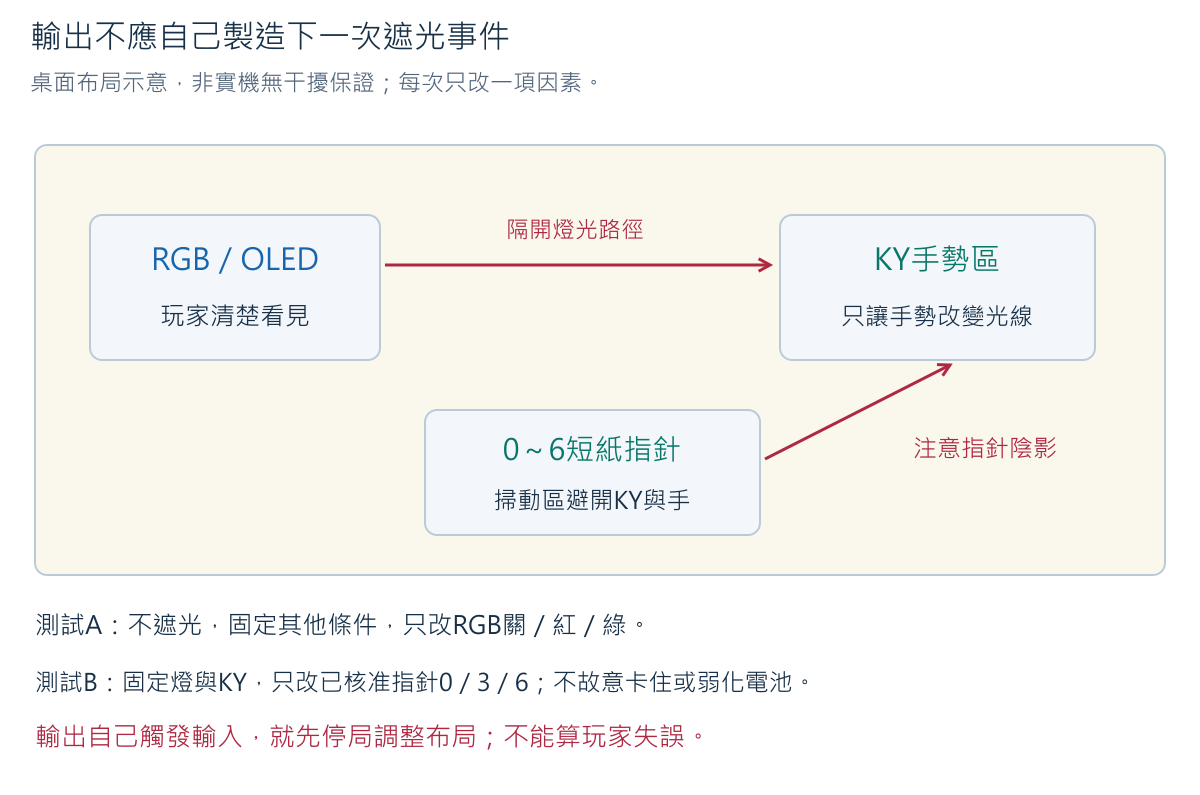

固定KY在同一位置、不遮光：先比較RGB關／紅／綠，再比較指針0／3／6（分項、核准安全範圍）。
只要輸出本身能造成SHADE事件，遊戲就可能自己加扣分。先調整一項位置、朝向或隔板，
再用相同條件比較；不能一邊把KY搬走一邊改門檻，然後說知道是哪個因素造成。
不要故意卡舵機或削弱供電，正常運作若出現壓降／重啟就停機查證。

## 9. 留下能追溯的log，不只拍到一個6

示例（非實測，為凸顯重點省略部分欄位；真實程式會輸出完整一行）：

```text
device_id=BOARD-T01 boot_id=1234abcd game_id=2 event_type=cover state=RUNNING value=5 unit=count valid=true reason=green_credit uptime_ms=12000 phase=GREEN light_raw=940 light_state=SHADE settled=true armed=false count_before=4 count_after=5 remaining_ms=24000 result=RUNNING angle_command=110 position_measured=false
```

這個例子假設本局從uptime6000開始：12000−6000=6000 ms，剩24000，屬綠段。
cover那一行先記count變更，接著才`writePointer()`，所以當行angle_command可能仍是舊值；
下一個pointer_command才記新映射。不能把不同event_type的先後順序誤讀成程式算錯。

| 欄位 | 意義與單位 |
|---|---|
| device_id | 自己的板卡識別；不要所有組永遠都寫BOARD-T01 |
| boot_id | 每次啟動產生的32-bit識別，供區分重啟；不是UTC，也不保證全世界永不重複 |
| game_id | 這次boot內接受Start的次序；重啟可回1，須連device與boot一起看 |
| uptime_ms | 本次開機後毫秒，不能跨boot直接相減當同一局 |
| event_type／reason | 發生什麼、為什麼，例如cover／red_penalty、result／deadline |
| phase | 該紀錄時程式燈色；結算後OFF，最後計分燈色要看前一筆cover |
| light_raw／light_state | ADC原始數與已確認分類；中間區可能保留舊state，要一起看settled |
| settled／armed／valid | 穩定、新事件準備、此分類資料可用；都不等於真實硬體永久可靠 |
| count_before／after、value | 本事件前後有效次數；value採更新後count，unit=count |
| remaining_ms／result | 剩餘毫秒及狀態；結果後凍結，不拿log增加行數當倒數 |
| angle_command／position_measured | 角度命令、是否實測位置；本程式後者永遠false |

倒數、RGB及指針不是各自維護一份count。顯示不一致時要中止查明，不能選一個看起來對的當答案。
課堂遊戲分數不等於平常成績；證據、理解與安全操作才依課程原評量規則處理。


## 10. 深入討論（Discussion）：明明遮了六次，為什麼不一定過關？

以下皆是已知條件的示例。先寫預測，再看參考答；實體操作不能精準製造的同輪情境，
使用本程式的主機端測試（host test）驗證，不要求冒險改線或同一實驗反覆重做。

### 10.1 40筆SHADE，為何不是40次？

**題目**：綠燈、原count0且已穩定未遮，遮住2秒，取得40筆SHADE。

**預期答案**：只加1。第一個確認的新邊緣消耗armed，後面都是同一狀態。
先看第3節時間圖，不把取樣頻率當動作頻率。若中間確實穩定放開，就不是題目的持續遮住條件。

### 10.2 五次綠、一次紅，按Finish？

**題目**：五次完整綠燈事件後一次紅燈事件，時間仍有10秒，按結束。

**預期答案**：0→1→2→3→4→5→4，Finish時4，FAILED，短聲一次。
錯誤是只算手揮六次，不扣紅燈。每次必須有新的穩定放開／遮光，不能只依玩家口述認定。

### 10.3 會欠分嗎？可以存第七次嗎？

**題目**：count0紅燈新遮，下一段綠燈新遮；另一次count6綠燈新遮。

**預期答案**：前者0→0→1；後者6→6。下界0、上界6，沒有欠分或儲存第七次。
再紅燈仍6→5。這叫飽和限制（clamping），不是忽略紅燈違規。

### 10.4 曾達6，為何按Finish失敗？

**題目**：count6後紅燈又做一次新遮光，之後Finish。

**預期答案**：6→5，結束時不足目標。應找最後cover與result的count，而不是之前顯示6的截圖。
若缺最後一段log，只能說證據不足，不能猜是硬體錯。

### 10.5 紅燈遮住一直到綠燈

**題目**：count3，在紅燈確認遮光扣一次，一直不放到綠燈；反過來綠跨紅呢？

**預期答案**：紅時3→2，綠時仍2；綠跨紅只在原綠事件加一次，換紅不補扣。
按第4.1圖追事件，不對每一筆SHADE套計分。這不代表可以在新紅燈事件不扣。

### 10.6 最後一次遮光與Finish同輪

**題目**：count5，elapsed12000 ms，同輪確認遮光與Finish。若改elapsed15000且count6？

**預期答案**：12000是綠，5→6再Finish成功；15000是紅，6→5再Finish失敗。
這是同一時間快照與固定處理順序的結果，不宣稱知道兩個實體動作誰先發生幾微秒。
常見錯誤是先做Finish，或先用上輪燈色算分。

### 10.7 畫面還有1秒，為何到期？

**題目**：count6，Finish事件與elapsed30000同輪；上一幀顯示1。

**預期答案**：到期優先，FAILED。顯示可向上取整且有刷新間隔，不能當精準截止時刻。
若顯示嚴重延遲，另記裝置品質問題並查證，不用這個案例宣稱任何延遲都公平。

### 10.8 中間值100 ms，與持續缺值有何差異？

**題目**：正常遊戲中短暫100 ms落中間帶，之後可穩定；另一次持續2000 ms無法穩定。

**預期答案**：短暫時不產生新事件、倒數繼續；持續超限ABORTED，靜音、停指針命令，
不算玩家輸。`f`注入測的是軟體缺值路徑，不證明實際拔線必定變−1。
已在硬體上執行的故障測試與純軟體注入分列，所有改線先斷電。

### 10.9 OLED3、指針4，選誰？

**題目**：log顯示count3、angle命令對應3，實物指在4。

**預期答案**：先中止與切外部OFF，保留三種證據。已知命令與邏輯一致，
仍要查供電、signal／共地、映射、紙盤與機構。OLED不是角度感測器，不能宣稱它證明指針到位。
沒有脈波或機構證據時，不直接判舵機壞掉。

### 10.10 怎樣提高難度，才知道改變的效果？

**題目**：把30秒改20秒、綠3秒改1秒、穩定150 ms改300 ms一起做，可以知道哪項最難嗎？

**預期答案**：不能。先改一項，固定其他設定、位置與比較方法，預測再測。
穩定時間長可能減少誤觸，也可能漏掉短手勢；縮短綠段可能根本沒有足夠機會。
固定序列基準有五段3秒綠，但六次需允許一段內多個完整循環；實際操作能力仍需試讀驗證。
隨機燈色僅選做，不把個人調過難度的遊戲分數與共同版本直接比較。


## 11. 最低驗證矩陣、完成條件與復原

下表的邏輯邊界先由提供的host測試核對，實機只做有不同目的的操作。
沒有硬體不能把此表預期填成實測通過。

| 測試 | 預期結果 | 證據層次 |
|---|---|---|
| 三局正常操作 | 每局新ID、無上一局armed／結果殘留、相同規則 | 真實整合log與必要實物觀察 |
| 目標前Finish、目標後Finish、到期未Finish | FAILED／SUCCESS／FAILED；各只結算一次 | 邏輯測試，實物短聲另驗 |
| 紅扣分、0／6上下界、跨色保持 | 對照10.2～5 | canonical程式host，代表性實物操作 |
| 同輪最後事件／Finish／到期 | 固定優先順序 | host精確時間，不要求手動毫秒級操作 |
| Start重按、Finish按住、雙鍵按住 | 不延時、不開始、持續中止不能被reset繞過 | host與已核准按鈕實測 |
| 100 ms過渡、持續無效、樣本過舊 | 短暫不計分；持續／過舊中止，不冒充玩家失敗 | 明示注入／延遲stub，不聲稱實體等同 |
| f→r→新穩定→c→z | 原因清除後才回待機，不自動Start／attach | log中的取消、穩定、clear、reset分開 |
| 結果凍結、短聲截止 | 後續遮光不改分、不重播聲音；最長聲長另量 | host + 聲音／反應實測 |
| 重啟 | 外部OFF後RST，IDLE、無自動舵機脈波命令 | log與實際啟動限制分列 |
| 光學／機械／供電干擾 | 輸出不應自造遮光事件、不抖／卡／重啟 | RGB／指針／負載實物觀察，未做寫待驗 |

三局正常指正常操作流程，不要求三次都成功；至少涵蓋一次成功、一次規則失敗，
再一局確認復原後不殘留。故障中止另以最小注入證據覆蓋，不把改線故障強塞進遊玩流程。

每位學生保存：自己參數與版本、兩組原基準、示例預測、原始log、三局結果、
失敗與中止區分、必要實物／供電觀察、Discussion推理及尚缺證據。
結果不符時先定位是輸入、穩定、事件、規則、輸出命令還是實物，不盲改多項參數。

收納：送x停止輸出，外部OFF取出電池，再拔USB；電表OFF。
確認無電後才拆正極、模組訊號與共地，端子絕緣、紙指針與舵盤妥善保存。
Week 8報告可引用此作品片段作可行性證據，不等於必須將遊戲當期末題目。

## 12. 技術來源與驗證界限

- [Arduino按鈕去抖](https://docs.arduino.cc/built-in-examples/digital/Debounce/)：接點彈跳基本問題；本課光線穩定與計分規則是教學設計。
- [Arduino不用delay計時](https://docs.arduino.cc/built-in-examples/digital/BlinkWithoutDelay/)：時間差的基本方法，不保證完整硬體每輪固定耗時。
- [Espressif ADC](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)：原始讀值、解析度與衰減；不是lux或過壓保護。
- [U8g2設定](https://github.com/olikraus/u8g2/wiki/u8g2setupcpp)、[函式](https://github.com/olikraus/u8g2/wiki/u8g2reference)：需搭配確切模組。
- [ESP32Servo](https://github.com/madhephaestus/ESP32Servo)：控制脈波與命令，不能當實際角度回傳。
- [Espressif隨機數API](https://docs.espressif.com/projects/esp-idf/en/stable/esp32s3/api-reference/system/random.html)：boot_id只是辨識輔助，不當作安全token或永久唯一ID；記錄檔另保存日期、裝置及版本，不為此啟用網路。

未進行實機驗證的項目包括新整合接線、全班GPIO、聲音截止、紙指針動作與供電、
OLED可讀性、光學干擾與完整初學者試讀。文件、編譯與主機邏輯測試通過，
只代表各自已檢查的範圍，不等於遊戲已可不經核准直接上電。
